###### Load Dependencies

In [1]:
from importlib import reload
import numpy as np
import scalers
from data import *
from classifications import *
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings

In [2]:
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [3]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
index_columns = [ 'CombinedSchedulesId', ]
nominal_columns = [ 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = index_columns + [ 'PY', 'CY', 'BY' ]
data_columns = [ 'MainAccount', 'Line' ]
all_columns = nominal_columns + numeric_columns
drop_columns = [ 'LineName', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
max_columns = data_columns + numeric_columns

# Read Excel, set index and load columns# Reload with corrected dtypes and padding for codes
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )

df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [4]:
ds = db.DataSource( df=df_numeric, target='BY' )
data = ds.data
X_training = ds.X_train
y_training = ds.y_train
X_testing = ds.X_test
y_testing = ds.y_test

In [5]:
# Standardized data
scaler = StandardScaler( )
std_data = scaler.train_transform( ds.data )
X_std_training = scaler.train_transform( X_training )
X_std_testing = scaler.train_transform( X_testing )

# Normalized data
normal = NormalScaler( )
nrm_data = normal.train_transform( ds.data )
X_nrm_training = normal.train_transform( X_training )
X_nrm_testing = normal.train_transform( X_testing )

In [6]:
pr = LeastSquares( )
pr.train( std_data, ds.targets )

In [7]:
prediction = pr.project( std_data, ds.targets )
prediction

array([1, 1, 1, ..., 1, 1, 1], shape=(2400,))

In [8]:
score = pr.score( std_data, ds.targets )
score


,F-Score,Recall Score,Accuracy Score,Precision Score,Balanced Accuracy
0,0.0,0.0,0.192917,0.0,0.001075
1,0.0,0.0,0.192917,0.0,0.001075
2,0.0,0.0,0.192917,0.0,0.001075
3,0.0,0.0,0.192917,0.0,0.001075
4,0.0,0.0,0.192917,0.0,0.001075
...,...,...,...,...,...
422,0.0,0.0,0.192917,0.0,0.001075
423,0.0,0.0,0.192917,0.0,0.001075
424,0.0,0.0,0.192917,0.0,0.001075
425,0.0,0.0,0.192917,0.0,0.001075


In [ ]:
analytics = pr.analyze( std_data, ds.targets )
analytics


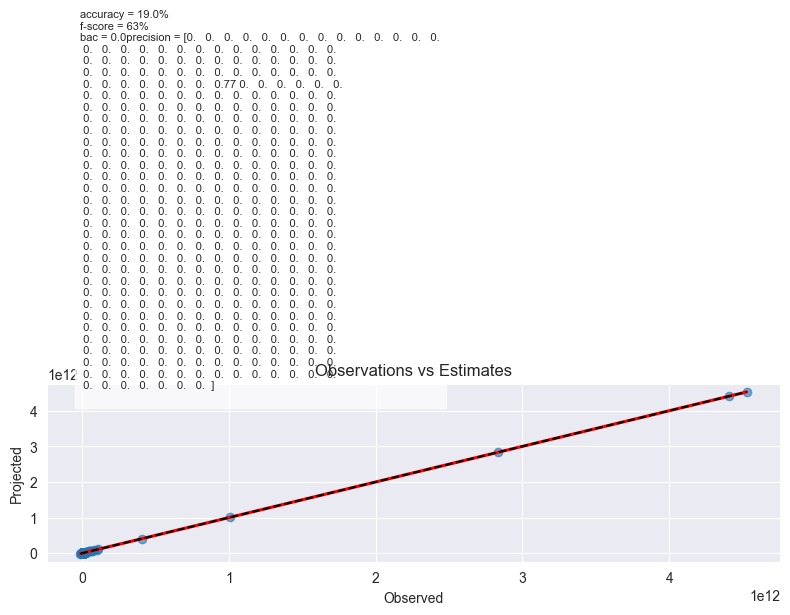

In [10]:
pr.scatter_plot( std_data, ds.targets )